# 02 — Classificação: presença bancária e arquétipos

> **Etapa 3 · ML** · Gera figuras de classificação.
> Escopo: discussão §4.2–4.3 e plano §4.3–4.4.

**Ressalva explícita:** este modelo **não é o índice e não substitui o IPB**. Ele estima a probabilidade de um município *já ser atrativo para rede física* — e o produto de negócio é o **resíduo**: municípios com perfil de bancarizado mas sem agência (falso negativo) = oportunidade não atendida, para cruzar com o rank V3.

**Prova:** split  80/20 com seed fixa; padronização ajustada **só no treino**; métricas calculadas **no teste**; tuning com `GridSearchCV` 5-fold no treino (grid pequeno e justificado — a aula pede tuning, não exaustão).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Sobe ate a raiz do projeto (pasta src/) para importar os modulos e
# achar data/, independente de onde o kernel iniciou.
caminho = Path.cwd()
while not (caminho / "src").is_dir() and caminho != caminho.parent:
    caminho = caminho.parent
sys.path.insert(0, str(caminho))

DATA = caminho / "data" / "processed"
FIGS = DATA / "figures"
FIGS.mkdir(exist_ok=True)
SEED = 42

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

from src.analytics.modelagem import (
    ALVOS,
    COLUNAS_IDENTIDADE,
    COLS_LOG,
    FEATURES_MODELO,
    FEATURES_SEM_PRESENCA,
    N_MUNICIPIOS_ESPERADO,
    montar_dataset_modelagem,
    padronizar,
    dividir_treino_teste,
)
from src.analytics import clustering as clu


Carrega o dataset e recria os labels do K-Means com a **mesma seed** do notebook 01 (reprodutível — validado em teste unitário). `K_ESCOLHIDO` precisa ser o **mesmo valor** do notebook 01.

In [2]:
df = pd.read_parquet(DATA / "modelagem.parquet")

K_ESCOLHIDO = 6  # MESMO valor do notebook 01
_, labels_km, _ = clu.ajustar_kmeans(df, FEATURES_MODELO, k=K_ESCOLHIDO)
df["cluster_kmeans"] = labels_km
df[["id_municipio", "nome_municipio", "cluster_kmeans", "flag_tem_agencia", "ipb", "rank"]].head()

,id_municipio,nome_municipio,cluster_kmeans,flag_tem_agencia,ipb,rank
0,1200401,Rio Branco,0,1,59.886902,86
1,1200179,Capixaba,1,0,30.070560,4135
2,1200328,Jordão,1,0,27.902725,4467
3,1200336,Mâncio Lima,1,0,33.903223,3354
4,1200351,Marechal Thaumaturgo,1,0,23.513906,5005


## 1. Alvo 1 — tem agência (`flag_tem_agencia`)

⚠️ **Correção metodológica** (detectada na primeira execução deste notebook): a versão inicial usava as 19 features e **todos os modelos acertaram 100% da prova (ROC-AUC = 1.0)**. Causa: entre as features estavam `agencias_por_100k_hab`, `depositos_per_capita` e `credito_per_capita` — variáveis que são **consequência** da presença bancária (cidade sem agência não tem agência por 100k hab nem depósito Estban). É como adivinhar se a pessoa tem carro olhando a foto dela dentro do carro — e com isso o produto de negócio (os resíduos) morria: zero falsos negativos.

**Decisão:** a classificação de presença usa só as **13 features exógenas** (`FEATURES_SEM_PRESENCA` — socioeconômicas + digitais). Assim o modelo responde "o *perfil* da cidade explica a presença?" — e a lista de oportunidade volta a existir.

Split estratificado (mantém o ~52/48 nos dois lados) + padronização sem vazar a prova.

In [3]:
ALVO = "flag_tem_agencia"
X_tr, X_te, y_tr, y_te = dividir_treino_teste(df, ALVO, test_size=0.2, features=FEATURES_SEM_PRESENCA)
X_tr_pad, X_te_pad, scaler = padronizar(X_tr, X_te)
print(f"features={len(FEATURES_SEM_PRESENCA)} (sem presenca) | treino={len(X_tr)} | teste={len(X_te)} | alvo no teste: {y_te.mean():.1%}")

features=13 (sem presenca) | treino=4456 | teste=1114 | alvo no teste: 52.3%


### Tuning (grid pequeno, 5-fold, só no treino)

Só os dois modelos-foco têm tuning; KNN e Árvore entram com os defaults da etapa (são teste secundário, decisão do grupo).

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

grids = {
    "random_forest": GridSearchCV(
        RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1),
        param_grid={"n_estimators": [200, 400], "max_depth": [None, 20]},
        cv=5, scoring="roc_auc", n_jobs=-1,
    ),
    "logistica": GridSearchCV(
        LogisticRegression(class_weight="balanced", random_state=SEED, max_iter=1000),
        param_grid={"C": [0.01, 0.1, 1, 10]},
        cv=5, scoring="roc_auc", n_jobs=-1,
    ),
}
for nome, grid in grids.items():
    grid.fit(X_tr_pad, y_tr)
    print(f"{nome}: {grid.best_params_} | ROC-AUC(CV)={grid.best_score_:.3f}")

random_forest: {'max_depth': 20, 'n_estimators': 400} | ROC-AUC(CV)=0.937


logistica: {'C': 10} | ROC-AUC(CV)=0.939


In [5]:
from src.analytics import classificacao as clf

MODELOS_TUNADOS = {
    "random_forest": grids["random_forest"].best_estimator_,
    "logistica": grids["logistica"].best_estimator_,
    "knn": clf.MODELOS["knn"],
    "arvore": clf.MODELOS["arvore"],
}
matriz = clf.treinar_classificadores(X_tr_pad, y_tr, X_te_pad, y_te, modelos=MODELOS_TUNADOS)
matriz.round(3)

,modelo,roc_auc,pr_auc,f1,precision,recall,acuracia,tempo_seg
0,random_forest,0.939,0.951,0.873,0.898,0.849,0.871,9.137
1,logistica,0.938,0.950,0.869,0.892,0.847,0.866,0.393
2,knn,0.909,0.923,0.842,0.824,0.861,0.831,0.084
3,arvore,0.909,0.911,0.833,0.846,0.820,0.828,0.107


Leitura da matriz
* ROC-AUC (ordenação — quão bem separa com/sem agência)
* PR-AUC (acerta os positivos?)
* F1/precision/recall (onde o limiar 0.5 acerta e onde tropeça) e tempo (custo).
* Métricas **no teste** — nenhum modelo viu esses municípios no treino.


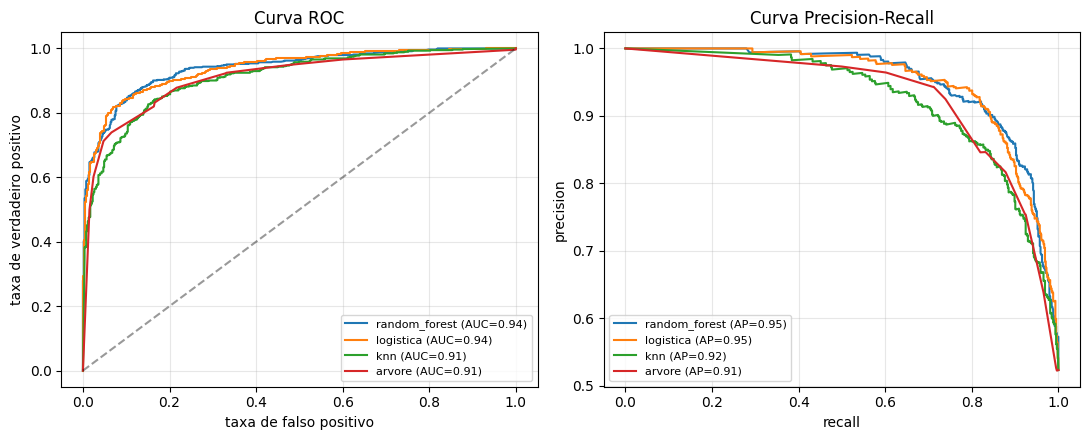

In [6]:
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for nome, modelo in MODELOS_TUNADOS.items():
    prob = modelo.predict_proba(X_te_pad)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, prob)
    axes[0].plot(fpr, tpr, label=f"{nome} (AUC={roc_auc_score(y_te, prob):.2f})")
    prec, rec, _ = precision_recall_curve(y_te, prob)
    axes[1].plot(rec, prec, label=f"{nome} (AP={average_precision_score(y_te, prob):.2f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set(title="Curva ROC", xlabel="taxa de falso positivo", ylabel="taxa de verdadeiro positivo")
axes[1].set(title="Curva Precision-Recall", xlabel="recall", ylabel="precision")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "02_curvas_roc_pr_agencia.png", dpi=110)
plt.show()

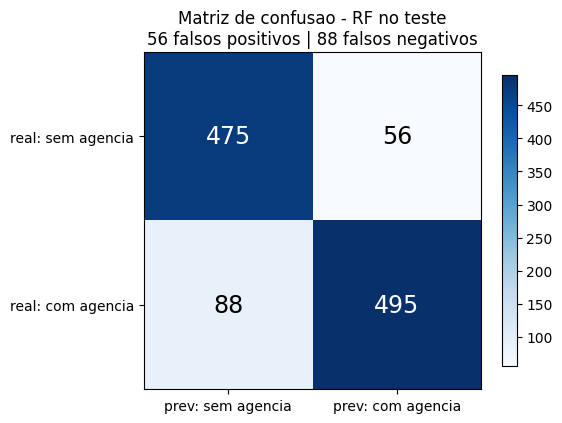

Quadrantes errados: 56 falsos positivos + 88 falsos negativos (os FN sao a lista de oportunidade)


In [7]:
melhor_rf = grids["random_forest"].best_estimator_
prob_rf_te = melhor_rf.predict_proba(X_te_pad)[:, 1]

cm = clf.matriz_confusao(y_te, prob_rf_te)

fig, ax = plt.subplots(figsize=(5.8, 4.6))
dados = cm.to_numpy()
im = ax.imshow(dados, cmap="Blues")
ax.set_xticks([0, 1], ["prev: sem agencia", "prev: com agencia"])
ax.set_yticks([0, 1], ["real: sem agencia", "real: com agencia"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, dados[i, j], ha="center", va="center", fontsize=17,
                color="white" if dados[i, j] > dados.max() / 2 else "black")
ax.set_title("Matriz de confusao - RF no teste\n56 falsos positivos | 88 falsos negativos")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
fig.savefig(FIGS / "02_matriz_confusao_agencia.png", dpi=110)
plt.show()
print("Quadrantes errados: 56 falsos positivos + 88 falsos negativos (os FN sao a lista de oportunidade)")

### O que explica "tem agência"? (não é a importância do IPB!)

⚠️ **Não confunda** com a importância do IPB (notebook 03): lá, `banda_larga_fixa_por_100_hab` domina (0,635) porque o índice combina taxas per capita e busca *oportunidade*. **Aqui a pergunta é outra**: o que explica a *presença de agência observada*?

**Como ler:** a importância por permutação é a queda de ROC-AUC ao embaralhar a variável. Embaralhar `populacao_total` derruba a métrica em ~0,29 → a capacidade de ordenar quase morre sem ela.

**O achado:** `populacao_total` domina sozinha (0,288) e as outras 12 variáveis juntas somam ~0,05 — **agência física é modelo de escala**: banco coloca onde tem gente, o resto do perfil da cidade quase não pesa. (Ressalva honesta: variáveis correlacionadas dividem importância na permutação — mas a dominância da população é esmagadora.)

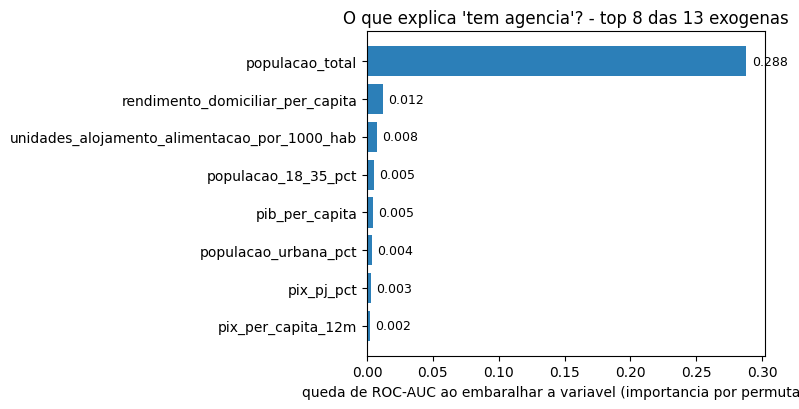

populacao_total sozinha: 0.288
outras 12 juntas:        0.046


In [8]:
importancia = clf.importancia_features(melhor_rf, X_te_pad, y_te)

fig, ax = plt.subplots(figsize=(8, 4.2))
top = importancia.head(8).sort_values()
ax.barh(top.index, top.values, color="#2c7fb8")
for i, v in enumerate(top.values):
    ax.text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlabel("queda de ROC-AUC ao embaralhar a variavel (importancia por permutacao)")
ax.set_title("O que explica 'tem agencia'? - top 8 das 13 exogenas")
fig.tight_layout()
fig.savefig(FIGS / "02_importancia_agencia.png", dpi=110)
plt.show()
print(f"populacao_total sozinha: {importancia.iloc[0]:.3f}")
print(f"outras 12 juntas:        {importancia.iloc[1:].sum():.3f}")

### Resíduos — o produto de negócio

Falsos negativos: probabilidade prevista alta **mas sem agência**. É a lista de oportunidade. Abaixo, ela cruzada com o rank do IPB V3 (scatter: quanto mais à direita, mais perfil de bancarizado; quanto mais acima, pior o rank).

In [9]:
X_todos = pd.DataFrame(
    scaler.transform(df[FEATURES_SEM_PRESENCA]),
    columns=FEATURES_SEM_PRESENCA,
    index=df.index,
)
prob_todos = pd.Series(melhor_rf.predict_proba(X_todos)[:, 1], index=df.index)

residuos = clf.extrair_residuos_oportunidade(
    df, ALVO, prob_todos,
    colunas=["id_municipio", "nome_municipio", "sigla_uf", "estrato_populacional", "ipb", "rank"],
)
print(f"{len(residuos)} municipios com perfil de bancarizado e SEM agencia (prob >= 0.5)")
residuos.head(15)

56 municipios com perfil de bancarizado e SEM agencia (prob >= 0.5)


,id_municipio,nome_municipio,sigla_uf,estrato_populacional,ipb,rank,prob_prevista
2294,5103254,Colniza,MT,pequena,49.350811,702,0.970000
4449,4202453,Bombinhas,SC,pequena,73.325112,1,0.937500
1530,3128105,Guapé,MG,pequena,39.573427,2230,0.880585
4557,4220000,Balneário Rincão,SC,pequena,53.020323,408,0.860000
1557,3133600,Itapeva,MG,pequena,58.295161,136,0.837500
5037,3553005,Taguaí,SP,pequena,48.611603,777,0.837340
252,2905909,Campo Alegre de Lourdes,BA,pequena,30.519391,4043,0.832500
4459,4203709,Canelinha,SC,pequena,47.439461,916,0.826748
4458,4203303,Campo Alegre,SC,pequena,50.121606,651,0.797500
315,2917102,Itororó,BA,pequena,34.187425,3294,0.797500


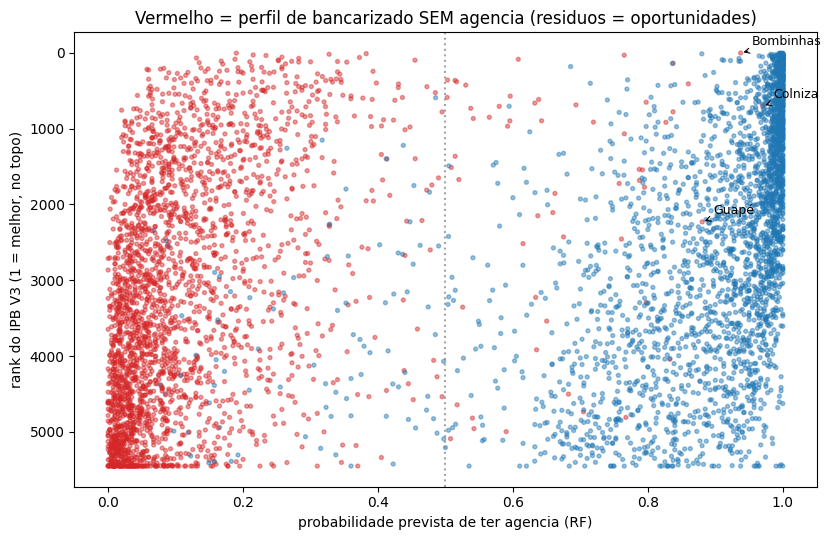

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
cores = np.where(df[ALVO] == 1, "#1f77b4", "#d62728")
ax.scatter(prob_todos, df["rank"], c=cores, s=8, alpha=0.45)
ax.axvline(0.5, color="gray", ls=":", alpha=0.7)
ax.invert_yaxis()  # rank 1 no topo (melhor oportunidade primeiro)
ax.set_xlabel("probabilidade prevista de ter agencia (RF)")
ax.set_ylabel("rank do IPB V3 (1 = melhor, no topo)")
ax.set_title("Vermelho = perfil de bancarizado SEM agencia (residuos = oportunidades)")
for _, r in residuos.head(3).iterrows():
    ax.annotate(r["nome_municipio"], (r["prob_prevista"], r["rank"]),
                textcoords="offset points", xytext=(8, 6), fontsize=9,
                arrowprops=dict(arrowstyle="->", color="black", lw=0.8))
fig.tight_layout()
fig.savefig(FIGS / "02_residuos_rank.png", dpi=110)
plt.show()

## 2. Alvo 2 — tem correspondente: **alvo degenerado, fora da matriz**

O dado vetou o experimento antes de ele começar: **100% dos 5.570 municípios têm ao menos 1 correspondente bancário** (rede BCB cobre o país inteiro — consistente com os 216 mil vínculos da discussão de negócio). Com uma única classe não existe classificação: acurácia seria 100% para qualquer modelo, e as demais métricas nem se calculam.

**Registro para o relatório (achado de negócio, não de modelo):** a camada de correspondentes bancários já atinge universalidade municipal — o "acesso bancário básico" via lotérica/correspondente não discrimina municípios. O que discrimina é a *intensidade* (correspondentes por 100k hab), que continua como feature dos demais modelos.

In [11]:
print("flag_tem_correspondente:")
print(df["flag_tem_correspondente"].value_counts().rename("n"))
print()
print("Conclusao: alvo com classe unica -> classificacao binaria inviavel.")
print("Mantemos correspondentes_por_100k_hab como FEATURE (intensidade), nao como alvo.")

flag_tem_correspondente:
flag_tem_correspondente
1    5570
Name: n, dtype: int64

Conclusao: alvo com classe unica -> classificacao binaria inviavel.
Mantemos correspondentes_por_100k_hab como FEATURE (intensidade), nao como alvo.


## 3. Classificador de arquétipos (multi-classe)

Rótulo = o próprio cluster do K-Means (100% dados) — e as preditoras são as **13 exógenas**: a pergunta é "dá para reconhecer o arquétipo da cidade só pelo perfil socioeconômico + digital, **sem olhar** a estrutura bancária instalada?".
- Para que serve: 
    - (1) diz quais variáveis definem cada arquétipo, 
    - (2) permite classificar município novo sem dados bancários e sem refazer o cluster 
    - (3) **mede a solidez dos grupos** — F1 macro alto = arquétipos bem separados; baixo = grupos que se misturam (e o relatório diz isso com número). `class_weight="balanced"` protege os clusters pequenos do domínio do grupo grande.

In [12]:
X_tr3, X_te3, y_tr3, y_te3 = dividir_treino_teste(df, "cluster_kmeans", features=FEATURES_SEM_PRESENCA)
X_tr3_pad, X_te3_pad, _ = padronizar(X_tr3, X_te3)

matriz_mc, confusao_mc = clf.treinar_multiclasse(X_tr3_pad, y_tr3, X_te3_pad, y_te3)
matriz_mc.round(3)

,modelo,f1_macro,acuracia,tempo_seg
0,random_forest,0.826,0.828,10.085
1,logistica,0.825,0.821,3.182


**Como ler a matriz de confusão dos arquétipos:**

- **Diagonal (azul escuro)** = acertos: municípios cujo arquétipo previsto bate com o real. Quanto mais escuro, mais municípios.
- **Fora da diagonal** = confusões: revela quais arquétipos se parecem entre si (ex.: se o modelo troca "Sem rede - renda baixa" por "Intermediário - tradicional", é porque essas cidades se sobrepõem no perfil).
- **% da linha** = dos municípios REAIS daquele grupo, quantos % foram classificados em cada arquétipo. Linha que soma ~100% na diagonal = grupo bem reconhecível só pelo perfil exógeno.

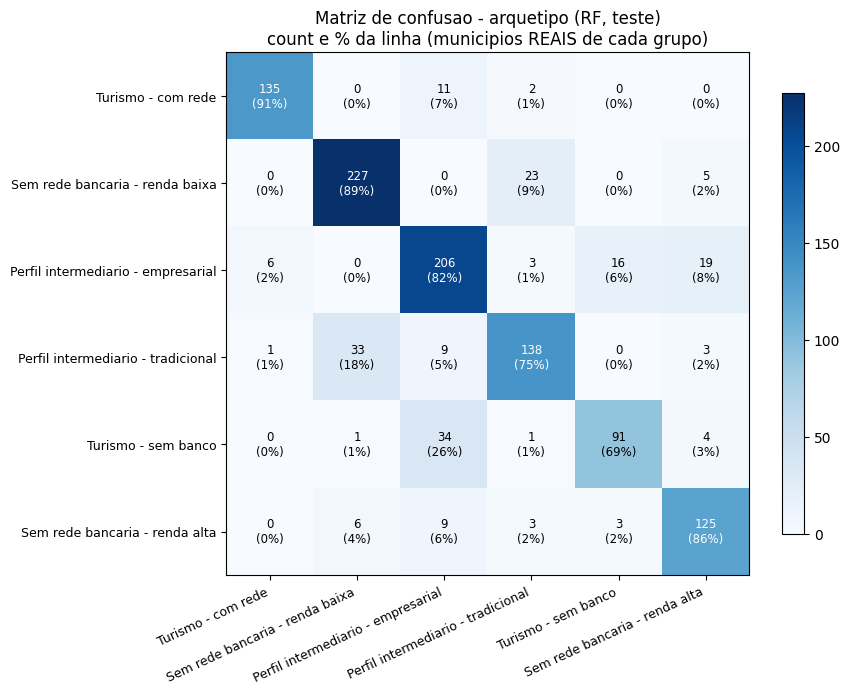

In [13]:
# Nomes reais dos arquetipos (valores reais, nao log — ver fix do nb03)
df_reais = df.copy()
df_reais[COLS_LOG] = np.expm1(df_reais[COLS_LOG])
nomes = clu.sugerir_nomes_perfis(clu.perfis_clusters(df_reais, FEATURES_MODELO, labels_km))

cm = confusao_mc["random_forest"].copy()
cm.index = [nomes[int(i.replace("obs_", ""))] for i in cm.index]
cm.columns = [nomes[int(c_.replace("prev_", ""))] for c_ in cm.columns]
pct = cm.div(cm.sum(axis=1), axis=0) * 100  # % por linha (dos reais daquele grupo)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(cm.to_numpy(), cmap="Blues")
ax.set_xticks(range(len(cm.columns)), cm.columns, rotation=25, ha="right", fontsize=9)
ax.set_yticks(range(len(cm.index)), cm.index, fontsize=9)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm.to_numpy()[i, j]}\n({pct.to_numpy()[i, j]:.0f}%)",
                ha="center", va="center", fontsize=8.5,
                color="white" if cm.to_numpy()[i, j] > cm.to_numpy().max() / 2 else "black")
ax.set_title("Matriz de confusao - arquetipo (RF, teste)\ncount e % da linha (municipios REAIS de cada grupo)")
fig.colorbar(im, ax=ax, shrink=0.75)
fig.tight_layout()
fig.savefig(FIGS / "02_matriz_confusao_arquetipos.png", dpi=110)
plt.show()

## 4. Decisões registradas deste notebook

1. Hiperparâmetros vencedores do tuning impressos na seção 1.
2. Matriz comparativa (4 modelos, alvo tem-agência) — a entrega “matriz de comparação de modelos” da rubrica, com os modelos comparados dentro da mesma classe.
3. **Alvo tem-correspondente degenerado (100/0)** — documentado como achado na seção 2; fora da matriz por decisão do dado, não nossa.
4. Lista de resíduos (falsos negativos) do alvo tem-agência — material para o cruzamento com o IPB no relatório.
5. F1 macro do classificador de arquétipos = medida de solidez dos clusters.